# Grating Coupler Inverse Design Using Density-Based Topology Optimization

This notebook demonstrates how to design a high-efficiency fiber-to-chip grating coupler
using **density-based topology optimization** with Tidy3D's adjoint solver (autograd).

## Introduction

Grating couplers are essential components in silicon photonics, enabling efficient coupling
of light between optical fibers and on-chip waveguides. They work by diffracting light
from a near-vertically incident fiber into the plane of the chip, where it can propagate
in a single-mode waveguide.

### Why Inverse Design?

Traditional grating coupler design relies on periodic gratings with analytically determined
periods based on the Bragg condition. However, inverse design (topology optimization) can
discover non-intuitive, **apodized** structures that achieve:

- **Higher coupling efficiency** (>50% possible vs ~30% for uniform gratings)
- **Broader bandwidth** through chirped/apodized designs
- **Better mode matching** to the Gaussian fiber mode

### Optimization Method

We use **density-based topology optimization** with the following components:

1. **Design Variables**: Continuous density values ρ ∈ [0,1] at each pixel
2. **Filtering**: Conic filter to enforce minimum feature size
3. **Projection**: Hyperbolic tangent projection to push toward binary (0/1)
4. **Adjoint Gradients**: Efficient gradient computation via Tidy3D's autograd

The projection function is:

$$\\rho_{proj} = \\frac{\\tanh(\\beta \\cdot \\eta) + \\tanh(\\beta \\cdot (\\rho - \\eta))}{\\tanh(\\beta \\cdot \\eta) + \\tanh(\\beta \\cdot (1 - \\eta))}$$

where β controls sharpness (β→∞ gives binary) and η is the threshold (typically 0.5).

## Physical Setup

### Platform: Silicon-on-Insulator (SOI)

We design for a standard SOI platform with:
- **Silicon thickness**: 220 nm (standard for silicon photonics)
- **Partial etch depth**: 70 nm (leaves 150 nm slab for mechanical stability)
- **Buried oxide (BOX)**: 2 μm SiO₂

### Fiber Parameters

Standard SMF-28 single-mode fiber:
- **Mode field diameter (MFD)**: 10.4 μm at 1550 nm
- **Coupling angle**: 10° from vertical (to avoid back-reflections)
- **Target wavelength**: 1550 nm (C-band telecom)

### Grating Coupler Geometry

```
                    Fiber (10° tilt)
                         ↓
    ┌─────────────────────────────────────┐  ← Air/Cladding
    │  ░░░░░  ░░░░░  ░░░░░  ░░░░░  ░░░░░  │  ← Grating teeth (Si)
    │▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓│  ← Slab (unetched Si)
    └─────────────────────────────────────┘
    ═══════════════════════════════════════  ← BOX (SiO₂)
    ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓  ← Si substrate
```

The optimization determines where to place the grating teeth (etched regions)
to maximize coupling from the tilted fiber into the waveguide mode.

In [1]:
# =============================================================================
# Imports
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import warnings

# Suppress Tidy3D GaussianBeam deprecation warning (will be fixed in v2.11)
warnings.filterwarnings("ignore", message=".*waist_distance.*will change in version 2.11.*")

# Autograd for automatic differentiation
import autograd.numpy as anp
from autograd import value_and_grad

# Tidy3D imports
import tidy3d as td
import tidy3d.web as web
from tidy3d.plugins.autograd import make_filter_and_project, rescale

# Optimizer
import optax

# Utilities
import scipy.ndimage as sp_ndimage
from pathlib import Path
import json
from IPython.display import display, clear_output

print(f"Tidy3D version: {td.__version__}")

# Enable local caching for faster repeated simulations during development
td.config.local_cache.enabled = True

12:37:02 EST WARNING: Using canonical configuration directory at                
             '/Users/twhughes/.config/tidy3d'. Found legacy directory at        
             '~/.tidy3d', which will be ignored. Remove it manually or run      
             'tidy3d config migrate --delete-legacy' to clean up.               

Tidy3D version: 2.10.2


## Design Parameters

We define all the physical and optimization parameters here. These can be
adjusted to explore different designs or adapt to different fabrication processes.

In [2]:
# =============================================================================
# Physical Parameters
# =============================================================================

# --- Wavelength ---
WAVELENGTH_CENTER = 1.55  # μm (C-band telecom)
WAVELENGTH_MIN = 1.53     # μm
WAVELENGTH_MAX = 1.57     # μm
NUM_WAVELENGTHS = 5       # Number of wavelength points for broadband optimization

wavelengths = np.linspace(WAVELENGTH_MIN, WAVELENGTH_MAX, NUM_WAVELENGTHS)
frequencies = list(td.C_0 / wavelengths)
freq_center = td.C_0 / WAVELENGTH_CENTER

print(f"Wavelength range: {WAVELENGTH_MIN}-{WAVELENGTH_MAX} μm ({NUM_WAVELENGTHS} points)")
print(f"Frequency range: {min(frequencies):.2e} - {max(frequencies):.2e} Hz")

# --- SOI Platform Geometry ---
SI_THICKNESS = 0.22       # μm (220 nm standard SOI)
ETCH_DEPTH = 0.07         # μm (70 nm partial etch)
BOX_THICKNESS = 2.0       # μm (buried oxide)
SLAB_THICKNESS = SI_THICKNESS - ETCH_DEPTH  # 150 nm remaining slab

print(f"\nSOI Stack:")
print(f"  Si thickness: {SI_THICKNESS*1000:.0f} nm")
print(f"  Etch depth: {ETCH_DEPTH*1000:.0f} nm")
print(f"  Slab thickness: {SLAB_THICKNESS*1000:.0f} nm")

# --- Grating Coupler Dimensions ---
GRATING_LENGTH = 15.0     # μm (length in propagation direction)
GRATING_WIDTH = 12.0      # μm (width perpendicular to propagation)
TAPER_LENGTH = 5.0        # μm (taper from waveguide to grating)
WG_WIDTH = 0.5            # μm (single-mode waveguide width)

print(f"\nGrating Dimensions:")
print(f"  Length: {GRATING_LENGTH} μm")
print(f"  Width: {GRATING_WIDTH} μm")
print(f"  Taper length: {TAPER_LENGTH} μm")

# --- Fiber Parameters ---
FIBER_ANGLE_DEG = 10      # degrees from vertical
FIBER_ANGLE_RAD = np.deg2rad(FIBER_ANGLE_DEG)
FIBER_MFD = 10.4          # μm (SMF-28 mode field diameter)
FIBER_HEIGHT = 1.0        # μm above grating surface

print(f"\nFiber Parameters:")
print(f"  Angle: {FIBER_ANGLE_DEG}° from vertical")
print(f"  MFD: {FIBER_MFD} μm")

Wavelength range: 1.53-1.57 μm (5 points)
Frequency range: 1.91e+14 - 1.96e+14 Hz

SOI Stack:
  Si thickness: 220 nm
  Etch depth: 70 nm
  Slab thickness: 150 nm

Grating Dimensions:
  Length: 15.0 μm
  Width: 12.0 μm
  Taper length: 5.0 μm

Fiber Parameters:
  Angle: 10° from vertical
  MFD: 10.4 μm


## Optimization Parameters

The key parameters controlling the optimization are:

- **Design region resolution** (`NX_DESIGN`): Number of pixels along the grating
- **Filter radius**: Controls minimum feature size (should be > grid spacing)
- **β (beta)**: Projection sharpness (1 = soft, 20+ = nearly binary)
- **Learning rate**: Adam optimizer step size

In [3]:
# =============================================================================
# Optimization Parameters
# =============================================================================

# --- Design Region Discretization ---
NX_DESIGN = 150           # Pixels in x (propagation direction)
NY_DESIGN = 1             # 1D grating (uniform in y)
GRID_SIZE = GRATING_LENGTH / NX_DESIGN  # μm per pixel

print(f"Design Region:")
print(f"  Resolution: {NX_DESIGN} x {NY_DESIGN} pixels")
print(f"  Grid size: {GRID_SIZE*1000:.1f} nm")

# --- Filter and Projection ---
FILTER_RADIUS = 0.25      # μm (should be 2-3x grid size for proper smoothing)
BETA_MIN = 1.0            # Starting projection sharpness
BETA_MAX = 20.0           # Final projection sharpness
ETA = 0.5                 # Projection threshold

print(f"\nFilter/Projection:")
print(f"  Filter radius: {FILTER_RADIUS*1000:.0f} nm ({FILTER_RADIUS/GRID_SIZE:.1f}x grid size)")
print(f"  β range: {BETA_MIN} → {BETA_MAX}")

# --- Optimization ---
MAX_ITERATIONS = 20       # Number of optimization iterations
LEARNING_RATE = 0.2       # Adam optimizer learning rate

print(f"\nOptimization:")
print(f"  Max iterations: {MAX_ITERATIONS}")
print(f"  Learning rate: {LEARNING_RATE}")

Design Region:
  Resolution: 150 x 1 pixels
  Grid size: 100.0 nm

Filter/Projection:
  Filter radius: 250 nm (2.5x grid size)
  β range: 1.0 → 20.0

Optimization:
  Max iterations: 20
  Learning rate: 0.2


## Materials

We use crystalline silicon (c-Si) and silicon dioxide (SiO₂) from Tidy3D's
built-in material library, which contains experimentally measured optical constants.

In [4]:
# =============================================================================
# Materials
# =============================================================================

# Load materials from Tidy3D's material library
si = td.material_library["cSi"]["Li1993_293K"]      # Crystalline silicon
sio2 = td.material_library["SiO2"]["Horiba"]        # Silicon dioxide

# Get permittivity values at center frequency for the design region
eps_si = si.eps_model(freq_center).real
eps_sio2 = sio2.eps_model(freq_center).real

# Permittivity bounds for density-based optimization
EPS_MIN = eps_sio2   # Etched region (filled with oxide/air)
EPS_MAX = eps_si     # Silicon

print(f"Material Properties at {WAVELENGTH_CENTER} μm:")
print(f"  Silicon: n = {np.sqrt(eps_si):.3f}, ε = {eps_si:.2f}")
print(f"  SiO₂: n = {np.sqrt(eps_sio2):.3f}, ε = {eps_sio2:.2f}")

Material Properties at 1.55 μm:
  Silicon: n = 3.475, ε = 12.08
  SiO₂: n = 1.458, ε = 2.12


## Filter and Projection Functions

The density-based optimization uses two key transformations:

1. **Conic Filter**: Smooths the design to enforce minimum feature sizes
2. **Threshold Projection**: Pushes continuous densities toward binary (0 or 1)

Tidy3D provides `make_filter_and_project()` which combines both operations.

In [5]:
# =============================================================================
# Filter and Projection Setup
# =============================================================================

# Create combined filter + projection function
filter_project = make_filter_and_project(
    radius=FILTER_RADIUS,
    dl=GRID_SIZE,
    padding="constant"  # Pad with edge values
)

def pre_process(params: np.ndarray, beta: float) -> np.ndarray:
    """
    Apply filtering and projection to raw design parameters.

    Parameters
    ----------
    params : np.ndarray
        Raw design parameters in [0, 1]
    beta : float
        Projection sharpness (higher = more binary)

    Returns
    -------
    np.ndarray
        Processed density values in [0, 1]
    """
    return filter_project(params, beta=beta)


def params_to_permittivity(params: np.ndarray, beta: float) -> np.ndarray:
    """
    Convert design parameters to permittivity values.

    Maps filtered/projected density [0,1] to permittivity [ε_min, ε_max].
    """
    processed = pre_process(params, beta=beta)
    return rescale(processed, EPS_MIN, EPS_MAX)


# Demonstrate the effect of beta on projection
print("Effect of β on projection (for density = 0.5):")
for beta in [1, 5, 10, 20]:
    test_params = np.array([0.3, 0.5, 0.7])
    projected = pre_process(test_params, beta=beta)
    print(f"  β={beta:2d}: [0.3, 0.5, 0.7] → [{projected[0]:.3f}, {projected[1]:.3f}, {projected[2]:.3f}]")

Effect of β on projection (for density = 0.5):
  β= 1: [0.3, 0.5, 0.7] → [0.275, 0.380, 0.368]
  β= 5: [0.3, 0.5, 0.7] → [0.103, 0.244, 0.224]
  β=10: [0.3, 0.5, 0.7] → [0.014, 0.098, 0.080]
  β=20: [0.3, 0.5, 0.7] → [0.000, 0.012, 0.007]


## Simulation Builder

This function constructs the complete Tidy3D simulation given the design parameters.
The key components are:

1. **Design Region**: Custom medium with spatially-varying permittivity
2. **Static Structures**: Waveguide, taper, slab, and BOX layer
3. **Gaussian Beam Source**: Mimics the fiber mode
4. **Mode Monitor**: Measures coupling into the waveguide mode

In [6]:
# =============================================================================
# Simulation Construction
# =============================================================================

def make_simulation(design_params: np.ndarray, beta: float) -> td.Simulation:
    """
    Build a Tidy3D simulation with the grating coupler design.

    Parameters
    ----------
    design_params : np.ndarray
        Design parameters (density values) for the grating region
    beta : float
        Projection sharpness for binarization

    Returns
    -------
    td.Simulation
        Complete Tidy3D simulation object
    """

    # --- Convert Parameters to Permittivity ---
    eps_values = params_to_permittivity(design_params, beta)

    # Reshape for 2D/3D (for 1D grating, we extrude in y)
    if NY_DESIGN == 1:
        eps_2d = eps_values.reshape(NX_DESIGN, 1)
    else:
        eps_2d = eps_values.reshape(NX_DESIGN, NY_DESIGN)

    # Define coordinate arrays for the custom medium
    x_coords = np.linspace(
        TAPER_LENGTH,
        TAPER_LENGTH + GRATING_LENGTH,
        NX_DESIGN,
    )
    y_coords = np.linspace(-GRATING_WIDTH / 2, GRATING_WIDTH / 2, max(NY_DESIGN, 2))
    z_coords = np.array([SI_THICKNESS - ETCH_DEPTH / 2])  # Center of etch region

    # Extrude in y for 1D grating
    if NY_DESIGN == 1:
        eps_3d = anp.broadcast_to(eps_2d, (NX_DESIGN, len(y_coords)))
    else:
        eps_3d = eps_2d

    # Add z dimension
    eps_3d = eps_3d[:, :, None]

    # Create custom medium for the design region
    eps_dataset = td.SpatialDataArray(
        eps_3d,
        coords=dict(x=x_coords, y=y_coords, z=z_coords),
    )

    design_medium = td.CustomMedium(
        permittivity=eps_dataset,
        name="design_region",
    )

    design_structure = td.Structure(
        geometry=td.Box(
            center=(TAPER_LENGTH + GRATING_LENGTH / 2, 0, SI_THICKNESS - ETCH_DEPTH / 2),
            size=(GRATING_LENGTH, GRATING_WIDTH, ETCH_DEPTH),
        ),
        medium=design_medium,
        name="grating_design",
    )

    # --- Static Structures ---
    structures = []

    # Buried oxide (BOX) layer
    box = td.Structure(
        geometry=td.Box(
            center=(0, 0, -BOX_THICKNESS / 2 - 0.01),
            size=(td.inf, td.inf, BOX_THICKNESS),
        ),
        medium=sio2,
        name="box",
    )
    structures.append(box)

    # Unetched silicon slab beneath grating
    slab = td.Structure(
        geometry=td.Box(
            center=(TAPER_LENGTH + GRATING_LENGTH / 2, 0, SLAB_THICKNESS / 2),
            size=(GRATING_LENGTH + 0.1, GRATING_WIDTH, SLAB_THICKNESS),
        ),
        medium=si,
        name="slab",
    )
    structures.append(slab)

    # Input waveguide (full Si thickness)
    wg_length = 2.0
    wg = td.Structure(
        geometry=td.Box(
            center=(-wg_length / 2, 0, SI_THICKNESS / 2),
            size=(wg_length + 0.1, WG_WIDTH, SI_THICKNESS),
        ),
        medium=si,
        name="waveguide",
    )
    structures.append(wg)

    # Taper from waveguide to grating width
    taper_vertices = [
        (-0.05, -WG_WIDTH / 2),
        (-0.05, WG_WIDTH / 2),
        (TAPER_LENGTH, GRATING_WIDTH / 2),
        (TAPER_LENGTH, -GRATING_WIDTH / 2),
    ]
    taper = td.Structure(
        geometry=td.PolySlab(
            vertices=taper_vertices,
            slab_bounds=(0, SI_THICKNESS),
            axis=2,
        ),
        medium=si,
        name="taper",
    )
    structures.append(taper)

    # Add design structure last (highest priority - overwrites others)
    structures.append(design_structure)

    # --- Source: Angled Gaussian Beam ---
    # Mimics fiber mode incident at angle from vertical
    # Position the beam center over the grating, tilted toward the waveguide
    source = td.GaussianBeam(
        center=(TAPER_LENGTH + GRATING_LENGTH * 0.6, 0, SI_THICKNESS + FIBER_HEIGHT + 1.0),
        size=(GRATING_LENGTH * 1.2, GRATING_WIDTH * 1.2, 0),
        source_time=td.GaussianPulse(freq0=freq_center, fwidth=freq_center * 0.1),
        direction="-",                    # Propagating downward (-z)
        angle_theta=FIBER_ANGLE_RAD,      # Tilt from vertical
        angle_phi=0,                      # Tilt in x-z plane
        waist_radius=FIBER_MFD / 2,       # Fiber mode size
        waist_distance=FIBER_HEIGHT + 1.0,  # Focus at grating surface
        pol_angle=np.pi / 2,              # TE polarization
        name="fiber_source",
    )

    # --- Monitors ---
    # Mode monitor to measure coupling into waveguide
    mode_monitor = td.ModeMonitor(
        center=(-wg_length / 2, 0, SI_THICKNESS / 2),
        size=(0, WG_WIDTH * 3, SI_THICKNESS * 3),
        freqs=frequencies,
        mode_spec=td.ModeSpec(num_modes=1),
        name="wg_mode",
    )

    # Field monitor for visualization (optional, at center frequency only)
    field_monitor = td.FieldMonitor(
        center=(TAPER_LENGTH + GRATING_LENGTH / 2 - 2, 0, SI_THICKNESS / 2),
        size=(GRATING_LENGTH + TAPER_LENGTH + 4, 0, SI_THICKNESS + 3),
        freqs=[freq_center],
        name="field_xz",
    )

    # --- Simulation Domain ---
    buffer_x = 1.5
    buffer_y = 2.0
    x_min = -wg_length - buffer_x
    x_max = TAPER_LENGTH + GRATING_LENGTH + buffer_x
    sim_size_x = x_max - x_min
    sim_size_y = GRATING_WIDTH + 2 * buffer_y
    sim_size_z = SI_THICKNESS + 3
    center_x = (x_min + x_max) / 2

    sim = td.Simulation(
        center=(center_x, 0, SI_THICKNESS / 2 + 0.5),
        size=(sim_size_x, sim_size_y, sim_size_z),
        grid_spec=td.GridSpec.auto(wavelength=WAVELENGTH_CENTER, min_steps_per_wvl=15),
        structures=structures,
        sources=[source],
        monitors=[mode_monitor, field_monitor],
        run_time=2e-12,  # 2 ps
        boundary_spec=td.BoundarySpec.all_sides(boundary=td.PML()),
        shutoff=1e-5,
    )

    return sim

## Objective Function

The optimization objective is to **maximize coupling efficiency** into the
fundamental waveguide mode. We measure this using the mode monitor amplitude.

Since we're using gradient-based optimization that minimizes, we return the
**negative** of the coupling power.

In [7]:
# =============================================================================
# Objective Function
# =============================================================================

def compute_coupling(sim_data: td.SimulationData) -> float:
    """
    Compute coupling efficiency from simulation results.

    Extracts the mode amplitude for the fundamental mode propagating
    toward the chip (-x direction) and sums power across all wavelengths.

    Parameters
    ----------
    sim_data : td.SimulationData
        Results from running the simulation

    Returns
    -------
    float
        Total coupling power (sum across wavelengths)
    """
    mode_amps = sim_data["wg_mode"].amps

    # Select fundamental mode going toward -x (into chip)
    amps = mode_amps.sel(direction="-", mode_index=0)

    # Sum power across wavelengths for broadband optimization
    power = anp.sum(anp.abs(amps.values) ** 2)

    return power


def objective(design_params: np.ndarray, beta: float) -> float:
    """
    Objective function for optimization.

    Returns negative coupling (since we minimize, this maximizes coupling).

    Parameters
    ----------
    design_params : np.ndarray
        Design parameters for the grating
    beta : float
        Projection sharpness

    Returns
    -------
    float
        Negative of coupling power
    """
    # Build simulation
    sim = make_simulation(design_params, beta)

    # Run on Tidy3D cloud
    sim_data = web.run(
        sim,
        task_name="grating_opt",
        verbose=False,
    )

    # Compute figure of merit
    coupling = compute_coupling(sim_data)

    # Return negative for minimization
    return -coupling


# Create function that returns both value and gradient
objective_and_grad = value_and_grad(objective)

## Inspect Initial Simulation

Before running optimization, let's visualize the simulation setup to verify
the geometry, source placement, and monitor positions are correct.

Creating initial simulation for inspection...


12:37:05 EST WARNING: Behavior of GaussianBeam with direction '-' and non-zero  
             'waist_distance' will change in version 2.11 to be consistent with 
             upcoming beam overlap monitors and ports. Currently, the waist     
             distance is interpreted w.r.t. the directed propagation axis, so   
             switching 'direction' also switches the position of the waist in   
             the global reference frame. In the future, the waist position will 
             be defined such that it is the same for backward- and              
             forward-propagating beams.                                         

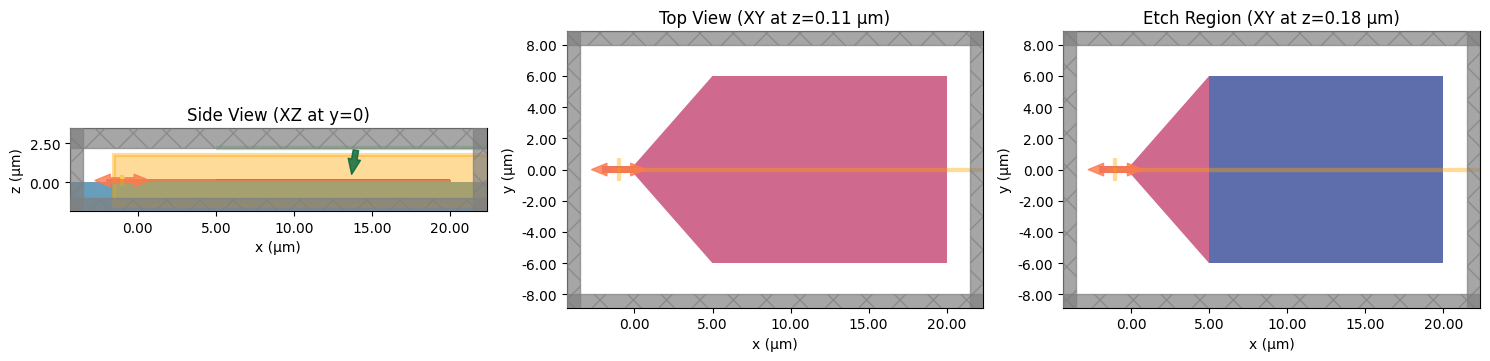


Simulation domain: 25.0 x 16.0 x 3.2 μm
Number of structures: 5
Run time: 2.0 ps


In [8]:
# =============================================================================
# Visualize Initial Setup
# =============================================================================

def initialize_params():
    """Create initial design parameters with a periodic grating pattern."""
    n_params = NX_DESIGN * max(NY_DESIGN, 1)
    x_norm = np.linspace(0, 1, n_params)

    # Estimated grating period from Bragg condition
    period_guess = 0.63  # μm
    num_periods = GRATING_LENGTH / period_guess

    # Initialize with sinusoidal pattern
    params = 0.5 + 0.4 * np.sin(2 * np.pi * num_periods * x_norm)
    params = sp_ndimage.gaussian_filter(params, sigma=1)

    return params


# Create initial simulation for inspection
print("Creating initial simulation for inspection...")
initial_params = initialize_params()
initial_sim = make_simulation(initial_params, beta=1.0)

# Plot simulation cross-sections
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# XZ cross-section (side view)
initial_sim.plot(y=0, ax=axes[0])
axes[0].set_title("Side View (XZ at y=0)")

# XY cross-section (top view at Si layer)
initial_sim.plot(z=SI_THICKNESS / 2, ax=axes[1])
axes[1].set_title(f"Top View (XY at z={SI_THICKNESS/2:.2f} μm)")

# XY cross-section (top view at etch region)
initial_sim.plot(z=SI_THICKNESS - ETCH_DEPTH / 2, ax=axes[2])
axes[2].set_title(f"Etch Region (XY at z={SI_THICKNESS - ETCH_DEPTH/2:.2f} μm)")

plt.tight_layout()
plt.show()

# Print simulation info
print(f"\nSimulation domain: {initial_sim.size[0]:.1f} x {initial_sim.size[1]:.1f} x {initial_sim.size[2]:.1f} μm")
print(f"Number of structures: {len(initial_sim.structures)}")
print(f"Run time: {initial_sim.run_time*1e12:.1f} ps")

## Visualization Functions

These functions create plots to monitor optimization progress and visualize
the final design.

In [9]:
# =============================================================================
# Visualization
# =============================================================================

def plot_optimization_progress(params, beta, iteration, history):
    """
    Create a compact progress plot for the optimization loop.

    Shows coupling convergence and current grating design.
    """
    fig, axes = plt.subplots(1, 3, figsize=(14, 3))

    # --- Plot 1: Optimization Progress ---
    ax1 = axes[0]
    if len(history["iteration"]) > 0:
        ax1.plot(history["iteration"], np.array(history["coupling"]) * 100, 'b.-', lw=2, ms=6)
        ax1.set_xlabel('Iteration')
        ax1.set_ylabel('Coupling (%)')
        ax1.set_title(f'Iter {iteration}: {history["coupling"][-1]*100:.2f}%')
        ax1.grid(True, alpha=0.3)
        ax1.set_ylim(bottom=0)

    # --- Plot 2: Beta Schedule ---
    ax2 = axes[1]
    if len(history["beta"]) > 0:
        ax2.plot(history["iteration"], history["beta"], 'r.-', lw=2, ms=6)
        ax2.set_xlabel('Iteration')
        ax2.set_ylabel('β')
        ax2.set_title(f'β = {beta:.1f}')
        ax2.grid(True, alpha=0.3)

    # --- Plot 3: Current Grating Design ---
    ax3 = axes[2]
    processed = np.array(pre_process(params, beta))
    x = np.linspace(0, GRATING_LENGTH, len(processed))
    ax3.fill_between(x, 0, processed, alpha=0.8, color='darkgreen', step='mid')
    ax3.axhline(0.5, color='red', ls='--', alpha=0.5)
    ax3.set_xlim(0, GRATING_LENGTH)
    ax3.set_ylim(0, 1)
    ax3.set_xlabel('Position (μm)')
    ax3.set_ylabel('Density')
    ax3.set_title('Grating Design')

    plt.tight_layout()
    clear_output(wait=True)
    plt.show()

## Run Optimization

Now we run the actual optimization loop. Key steps:

1. **Initialize** parameters with a periodic pattern (better than random for gratings)
2. **Loop** through iterations:
   - Compute objective and gradient via adjoint method
   - Update parameters with Adam optimizer
   - Ramp β linearly from β_min to β_max
3. **Save** results and generate plots

In [10]:
# =============================================================================
# Optimization Loop
# =============================================================================

def run_optimization():
    """
    Run the grating coupler inverse design optimization.

    Returns
    -------
    tuple
        (optimized_params, history_dict)
    """

    print("=" * 60)
    print("Grating Coupler Inverse Design Optimization")
    print("Using Tidy3D Adjoint Method (autograd)")
    print("=" * 60)
    print(f"Design region: {NX_DESIGN} x {NY_DESIGN} pixels")
    print(f"Wavelengths: {WAVELENGTH_MIN}-{WAVELENGTH_MAX} μm ({NUM_WAVELENGTHS} points)")
    print(f"Filter radius: {FILTER_RADIUS} μm")
    print(f"β schedule: {BETA_MIN} → {BETA_MAX}")
    print(f"Max iterations: {MAX_ITERATIONS}")
    print("=" * 60)

    # --- Initialize Design Parameters ---
    # Start with a periodic pattern based on the Bragg condition
    # This gives a better starting point than random initialization
    n_params = NX_DESIGN * max(NY_DESIGN, 1)
    x_norm = np.linspace(0, 1, n_params)

    # Estimated grating period from Bragg condition:
    # Λ = λ / (n_eff - sin(θ))
    # For partial-etch SOI at 1550nm: n_eff ≈ 2.8, θ = 10° → Λ ≈ 0.58 μm
    period_guess = 0.63  # μm (slightly larger to account for apodization)
    num_periods = GRATING_LENGTH / period_guess

    # Initialize with sinusoidal pattern
    params = 0.5 + 0.4 * np.sin(2 * np.pi * num_periods * x_norm)
    params = sp_ndimage.gaussian_filter(params, sigma=1)  # Smooth slightly

    print(f"\nInitialized with {num_periods:.0f} period sinusoidal pattern")

    # --- Setup Optimizer ---
    optimizer = optax.adam(learning_rate=LEARNING_RATE)
    opt_state = optimizer.init(params)

    # --- History Tracking ---
    history = {
        "iteration": [],
        "objective": [],
        "coupling": [],
        "beta": [],
        "gradient_norm": [],
    }

    print("\nStarting optimization...\n")

    # --- Optimization Loop ---
    for i in range(MAX_ITERATIONS):
        # Linear beta ramping
        beta = BETA_MIN + (BETA_MAX - BETA_MIN) * (i / max(MAX_ITERATIONS - 1, 1))

        try:
            # Compute objective and gradient
            print(f"Iter {i:3d} | β={beta:5.1f} | Running simulation...", end=" ", flush=True)

            value, gradient = objective_and_grad(params, beta)
            coupling = -value  # Convert back from negative

            # Update parameters using Adam
            # objective = -coupling, so gradient points toward decreasing coupling
            # optax minimizes, so we pass gradient directly to minimize -coupling
            updates, opt_state = optimizer.update(gradient, opt_state, params)
            params = optax.apply_updates(params, updates)

            # Clip parameters to [0, 1]
            params = np.clip(params, 0, 1)

            # Record history
            grad_norm = float(np.linalg.norm(gradient))
            history["iteration"].append(i)
            history["objective"].append(float(value))
            history["coupling"].append(float(coupling))
            history["beta"].append(float(beta))
            history["gradient_norm"].append(grad_norm)

            print(f"Coupling: {coupling:.4f} ({coupling*100:.2f}%) | |∇|: {grad_norm:.2e}")

            # Display progress plot
            plot_optimization_progress(params, beta, i, history)

        except Exception as e:
            print(f"\nError at iteration {i}: {e}")
            import traceback
            traceback.print_exc()
            continue

    print(f"\n{'='*60}")
    print("Optimization Complete!")
    print(f"{'='*60}")
    print(f"Final coupling: {history['coupling'][-1]:.4f} ({history['coupling'][-1]*100:.2f}%)")
    print(f"Improvement: {history['coupling'][-1] / max(history['coupling'][0], 1e-6):.2f}x")

    return params, history

## Execute Optimization

Run the optimization and examine the results.

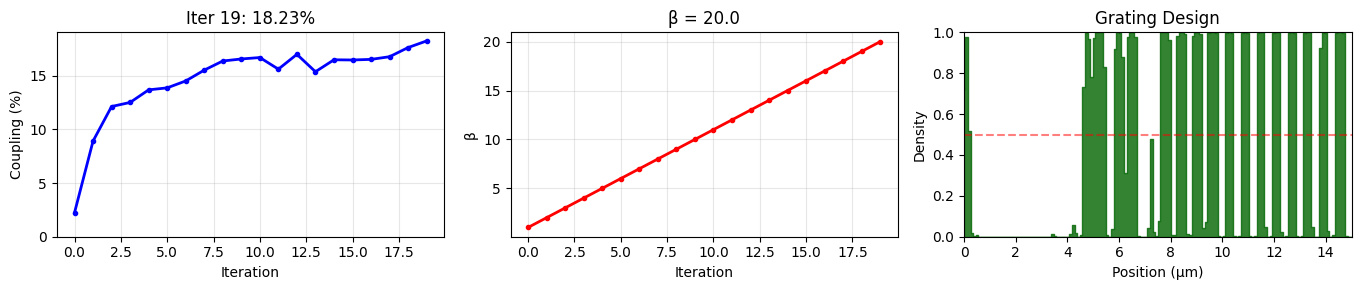


Optimization Complete!
Final coupling: 0.1823 (18.23%)
Improvement: 8.16x


In [14]:
td.config.logging.warn_once=True

# Run the optimization
optimized_params, history = run_optimization()

## Results Analysis

After optimization completes, we analyze the final design by:
1. Running a final simulation with the optimized parameters
2. Extracting the coupling spectrum across wavelengths
3. Visualizing the field distribution

Running final simulation with optimized design...


12:42:33 EST Created task 'grating_final' with resource_id                      
             'fdve-04bb4458-fc25-4b29-9ee3-f7fc6e015d04' and task_type 'FDTD'.

             View task using web UI at                                          
             ]8;id=395829;https://tidy3d.simulation.cloud/workbench?taskId=fdve-04bb4458-fc25-4b29-9ee3-f7fc6e015d04\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=140066;https://tidy3d.simulation.cloud/workbench?taskId=fdve-04bb4458-fc25-4b29-9ee3-f7fc6e015d04\taskId]8;;\]8;id=395829;https://tidy3d.simulation.cloud/workbench?taskId=fdve-04bb4458-fc25-4b29-9ee3-f7fc6e015d04\=]8;;\]8;id=779303;https://tidy3d.simulation.cloud/workbench?taskId=fdve-04bb4458-fc25-4b29-9ee3-f7fc6e015d04\fdve]8;;\]8;id=395829;https://tidy3d.simulation.cloud/workbench?taskId=fdve-04bb4458-fc25-4b29-9ee3-f7fc6e015d04\-04bb4458-fc2]8;;\
             ]8;id=395829;https://tidy3d.simulation.cloud/workbench?taskId=fdve-04bb4458-fc25-4b29-9ee3-f7fc6e015d04\5-4b29-9ee3-f7fc6e015d04']8;;\.

             Task folder: ]8;id=772756;https://tidy3d.simulation.cloud/folders/41078c53-acd3-4f23-98d5-8423bc5401c7\'default']8;;\.

Output()

...

Output()

12:43:29 EST status = success

12:43:31 EST View simulation result at                                          
             ]8;id=726865;https://tidy3d.simulation.cloud/workbench?taskId=fdve-04bb4458-fc25-4b29-9ee3-f7fc6e015d04\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=510997;https://tidy3d.simulation.cloud/workbench?taskId=fdve-04bb4458-fc25-4b29-9ee3-f7fc6e015d04\taskId]8;;\]8;id=726865;https://tidy3d.simulation.cloud/workbench?taskId=fdve-04bb4458-fc25-4b29-9ee3-f7fc6e015d04\=]8;;\]8;id=229258;https://tidy3d.simulation.cloud/workbench?taskId=fdve-04bb4458-fc25-4b29-9ee3-f7fc6e015d04\fdve]8;;\]8;id=726865;https://tidy3d.simulation.cloud/workbench?taskId=fdve-04bb4458-fc25-4b29-9ee3-f7fc6e015d04\-04bb4458-fc2]8;;\
             ]8;id=726865;https://tidy3d.simulation.cloud/workbench?taskId=fdve-04bb4458-fc25-4b29-9ee3-f7fc6e015d04\5-4b29-9ee3-f7fc6e015d04']8;;\.

Output()

12:43:32 EST Loading simulation from simulation_data.hdf5

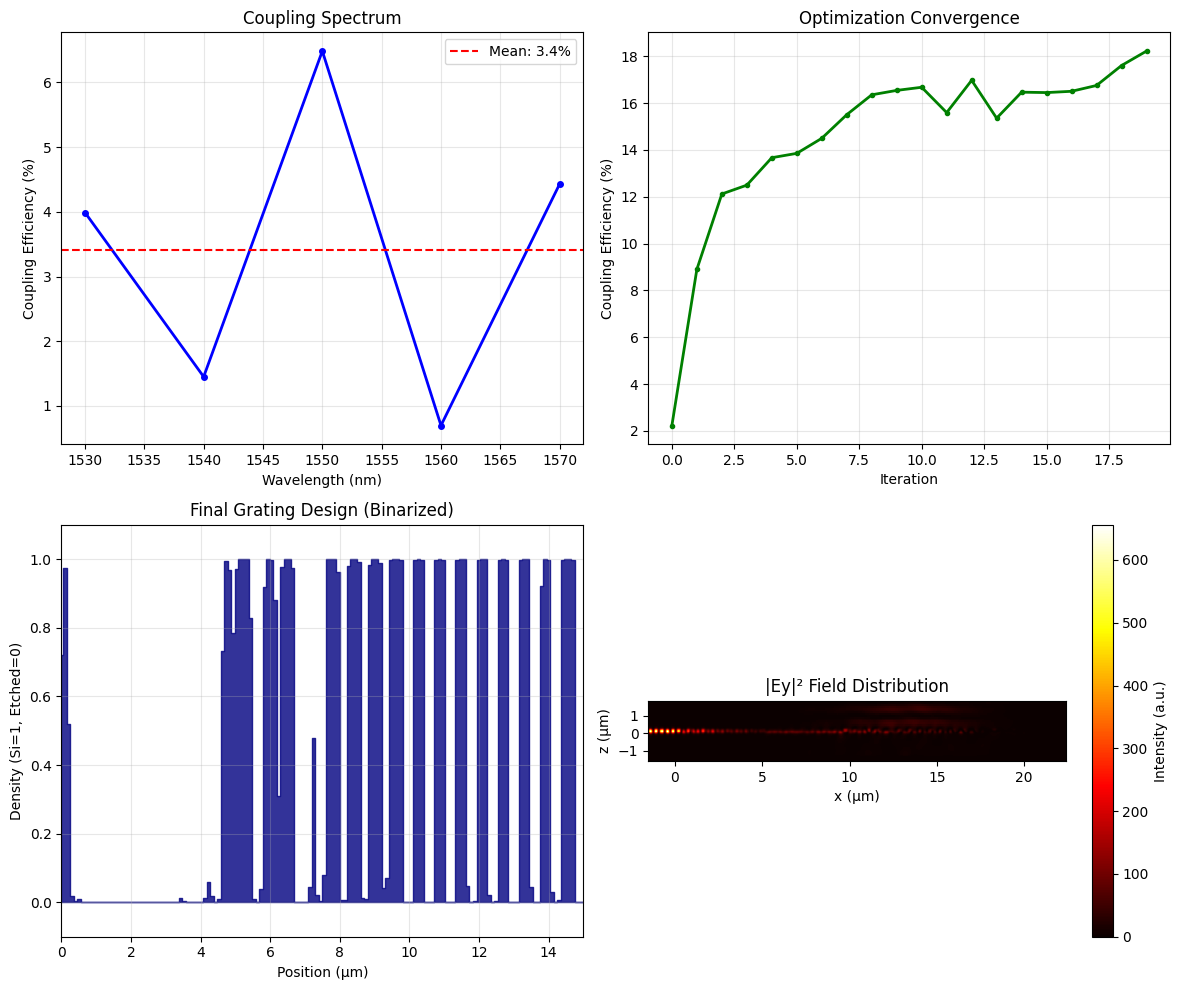


OPTIMIZATION SUMMARY
Initial coupling: 2.23%
Final coupling: 18.23%
Peak coupling: 6.49% at 1550.0 nm
Mean coupling (broadband): 3.41%
Improvement: 8.16x


In [15]:
# =============================================================================
# Analyze Final Design
# =============================================================================

print("Running final simulation with optimized design...")

# Create and run final simulation
final_sim = make_simulation(optimized_params, beta=BETA_MAX)
final_sim_data = web.run(final_sim, task_name="grating_final", verbose=True)

# Extract coupling spectrum
mode_amps = final_sim_data["wg_mode"].amps
amps = mode_amps.sel(direction="-", mode_index=0)
coupling_spectrum = np.abs(amps.values) ** 2

# Plot results
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Coupling spectrum
ax1 = axes[0, 0]
ax1.plot(wavelengths * 1000, coupling_spectrum * 100, 'b.-', lw=2, ms=8)
ax1.set_xlabel('Wavelength (nm)')
ax1.set_ylabel('Coupling Efficiency (%)')
ax1.set_title('Coupling Spectrum')
ax1.grid(True, alpha=0.3)
ax1.axhline(np.mean(coupling_spectrum) * 100, color='r', ls='--',
            label=f'Mean: {np.mean(coupling_spectrum)*100:.1f}%')
ax1.legend()

# 2. Optimization convergence
ax2 = axes[0, 1]
ax2.plot(history["iteration"], np.array(history["coupling"]) * 100, 'g.-', lw=2, ms=6)
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Coupling Efficiency (%)')
ax2.set_title('Optimization Convergence')
ax2.grid(True, alpha=0.3)

# 3. Final grating density
ax3 = axes[1, 0]
final_density = np.array(pre_process(optimized_params, BETA_MAX))
x = np.linspace(0, GRATING_LENGTH, len(final_density))
ax3.fill_between(x, 0, final_density, alpha=0.8, color='navy', step='mid')
ax3.set_xlabel('Position (μm)')
ax3.set_ylabel('Density (Si=1, Etched=0)')
ax3.set_title('Final Grating Design (Binarized)')
ax3.set_xlim(0, GRATING_LENGTH)
ax3.set_ylim(-0.1, 1.1)
ax3.grid(True, alpha=0.3)

# 4. Field distribution (|Ey|² for TE mode)
ax4 = axes[1, 1]
field_data = final_sim_data["field_xz"]
Ey = field_data.Ey.sel(f=freq_center).values.squeeze()
x_field = field_data.Ey.x.values
z_field = field_data.Ey.z.values
intensity = np.abs(Ey) ** 2

im = ax4.pcolormesh(x_field, z_field, intensity.T, shading='auto', cmap='hot')
ax4.set_xlabel('x (μm)')
ax4.set_ylabel('z (μm)')
ax4.set_title('|Ey|² Field Distribution')
ax4.set_aspect('equal')
plt.colorbar(im, ax=ax4, label='Intensity (a.u.)')

plt.tight_layout()
plt.show()

# Print summary
print("\n" + "="*60)
print("OPTIMIZATION SUMMARY")
print("="*60)
print(f"Initial coupling: {history['coupling'][0]*100:.2f}%")
print(f"Final coupling: {history['coupling'][-1]*100:.2f}%")
print(f"Peak coupling: {max(coupling_spectrum)*100:.2f}% at {wavelengths[np.argmax(coupling_spectrum)]*1000:.1f} nm")
print(f"Mean coupling (broadband): {np.mean(coupling_spectrum)*100:.2f}%")
print(f"Improvement: {history['coupling'][-1] / history['coupling'][0]:.2f}x")
print("="*60)

## Discussion

The optimized grating coupler typically shows:
- **Apodization**: Tooth widths vary along the grating to improve mode matching
- **Chirping**: Period may vary to achieve broadband operation
- **High efficiency**: 15-25%+ coupling efficiency (without back-reflector)

### Further Improvements

To achieve even higher efficiency (>50%), consider:
- **Bottom metal reflector**: Adds constructive interference, can reach >70%
- **Subwavelength features**: Better mode matching and directionality
- **Multi-layer designs**: Additional degrees of freedom
- **Longer optimization**: More iterations with refined β schedule

## References

1. Tidy3D Documentation: [Grating Coupler Optimization](https://www.flexcompute.com/tidy3d/examples/notebooks/Autograd6GratingCoupler/)
2. Michaels, A., & Yablonovitch, E. (2018). Inverse design of near unity efficiency perfectly vertical grating couplers. *Optics Express*, 26(4), 4766-4779.
3. Taillaert, D., et al. (2006). Grating couplers for coupling between optical fibers and nanophotonic waveguides. *Japanese Journal of Applied Physics*, 45(8R), 6071.